# Does Ferrari's stock rev up when Ferrari wins a race? 🏁📈
### The tifosi brand-halo folklore — a coin flip, and the one whisper isn't even about the fans

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Fan--halo_or_fundamentals%3F: Misattributed](https://img.shields.io/badge/Fan--halo_or_fundamentals%3F-Misattributed-8b949e?style=flat-square)

Ferrari is the one company on the stock market whose *brand is a racing team*. So it's an irresistible idea: the Scuderia wins a Formula 1 Grand Prix on Sunday, the tifosi are euphoric, the world's cameras are on the prancing horse — surely `RACE` (Ferrari's ticker, and yes that really is the ticker) gets a Monday-morning pop. It's the Ferrari-flavoured cousin of a real academic finding: a 2007 study showed national stock markets genuinely sag when a country's football team is knocked out of the World Cup. Mood moves markets. Does a Ferrari win move Ferrari?

We tested it on every Ferrari Grand Prix win since the company went public in 2015 — 24 of them.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the era split? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 24 Ferrari wins hardcoded from STATS F1 / Formula1.com; RACE measured against the S&P 500 (`SPY`) so a market-wide Monday doesn't get mistaken for a Ferrari effect. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ferrari_f1 import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=5.0)
    INC = EV[EV["included"]]
    CONT = INC[INC["era"] == "contender"]
    SPOR = INC[INC["era"] == "sporadic"]
else:
    PRICES = EV = INC = CONT = SPOR = None
print("real cache present:", HAVE_REAL, "| Ferrari wins:", len(data.EVENTS),
      "| resolved:", (0 if INC is None else len(INC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_wins': 24, 'n_contender': 11, 'n_sporadic': 13, 'fp': '5e3d6de14719', 'panel_rows': 2701, 'd_mean': 0.276, 'd_t': 1.181, 'd_hit': 13, 'd_n': 24, 'd_lo': 35.1, 'd_hi': 72.1, 'wk_mean': 0.862, 'wk_t': 1.385, 'wk_hit': 12, 'wk_n': 24, 'wk_lo': 31.4, 'wk_hi': 68.6, 'wki_mean': 1.314, 'wki_t': 2.285, 'wki_n': 21, 'pl_d_p': 0.214, 'pl_d_mean': 0.032, 'pl_d_sd': 0.318, 'pl_wk_p': 0.159, 'pl_wk_mean': 0.155, 'pl_wki_p': 0.062, 'cap_g': 0.578, 'cap_gt': 1.06, 'cap_n5': 0.478, 'cap_t5': 0.88, 'cap_n10': 0.378, 'cap_t10': 0.69, 'pl_cap_p': 0.274, 'pl_cap_mean': 0.056, 'cont_d_mean': 0.386, 'cont_d_t': 1.04, 'cont_wk_mean': 2.471, 'cont_wk_t': 2.732, 'spor_d_mean': 0.183, 'spor_d_t': 0.595, 'spor_wk_mean': -0.499, 'spor_wk_t': -0.739, 'welch_d': 0.42, 'welch_wk': 2.631, 'cont_wk_pl_p': 0.017, 'cont_wk_pl_mean': 0.149, 'car': {0: 0.0, 1: 0.276, 2: 0.287, 3: 0.649, 4: 0.969, 5: 0.862}, 'wins_by_season': {2016: 0, 2017: 5, 2018: 6, 2019: 3, 2020: 0, 2021: 0, 2022: 4, 2023: 1, 2024: 5, 2025: 0}, 'syn_null_mean': 0.43, 'syn_null_sd': 1.01, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_planted1_t': 2.34, 'syn_planted2_t': 5.73}


real cache present: True | Ferrari wins: 24 | resolved: 24


## The answer first

| Question | Answer |
|---|---|
| Does RACE pop the Monday after a win? | **No.** Up **+0.28%** vs the market on average — but the win-Mondays go up only **13/24** times (54%, a coin flip), and a *random* Monday does just as well (**p = 0.21**). |
| Is there anything over the following week? | **A whisper, +0.86%** — but it doesn't clear the desk's bar either (*t* = 1.39), and a random week matches it 16% of the time. |
| Could you have traded it? | **No.** Buy the first moment you actually *could* (after the result is public) and hold a week: **+0.48%** net of costs — statistically a random draw. |
| So is the folklore just wrong? | **It's mislabeled.** The one signal that *does* survive lives entirely in 2017-18 — when a Ferrari win meant a live *title* fight — and flips negative for the one-off wins that are pure fan celebration. What little moves RACE is the championship, not the crowd. |

> The prancing horse doesn't pull the stock. When it looks like it does, it's the scoreboard talking, not the tifosi.

## 1 · The claim

> *"Ferrari isn't just a carmaker — it's a racing team you can buy shares in. When the Scuderia wins a Grand Prix, the tifosi are euphoric, the brand is everywhere, and that wave of sentiment lifts `RACE` the next trading day."*

It rides on real science: Edmans, García & Norli (2007) found national stock markets really do fall the day after a country is *eliminated* from the football World Cup — sports sentiment genuinely moves money. And individual listed football clubs' shares move on match results. Ferrari is the closest thing the market has to a listed race team, so the claim is the natural test. Nobody has published it. We did.

## 2 · So what?

If real, it would be a delightful, tradable quirk: a globally-televised, calendar-known, emotion-drenched event — a Ferrari win — that nudges a specific liquid stock every couple of weeks in season. Buy Friday, sell into the tifosi Monday, repeat ~5 times a good year. It would also be a clean demonstration that pure fan sentiment, not fundamentals, prices a real company. We wanted to know: is it there?

## 3 · How would we even know?

- **The calendar.** All **24** Ferrari Formula 1 wins since the 2015 NYSE listing, hardcoded with the exact (Sunday) race date. Ferrari were *winless* in 2016, 2020, 2021 and 2025 — so the wins run 2017→2024.
- **The stock.** `RACE` (Ferrari N.V.) measured against `SPY` (the S&P 500), so we're looking at Ferrari's move *beyond* whatever the whole market did that day.
- **The window.** Every race is on a Sunday (markets shut), so nobody can act until Monday. We measure from Friday's close (before the race) to Monday's close (after) — the honest 'win pop' — and out to a week.
- **The honesty check.** A random-calendar placebo (does a random Monday pop just as often?), a costed trade you could *actually* have placed, and a split of the wins into 'title-contender years' vs 'one-off wins' to see whether any effect is fans or fundamentals.

## 4 · The teardown — let's actually look

**First, a reality check on how often this even happens.** Ferrari's 'brand is winning' — but for a chunk of the listed era they didn't win at all.

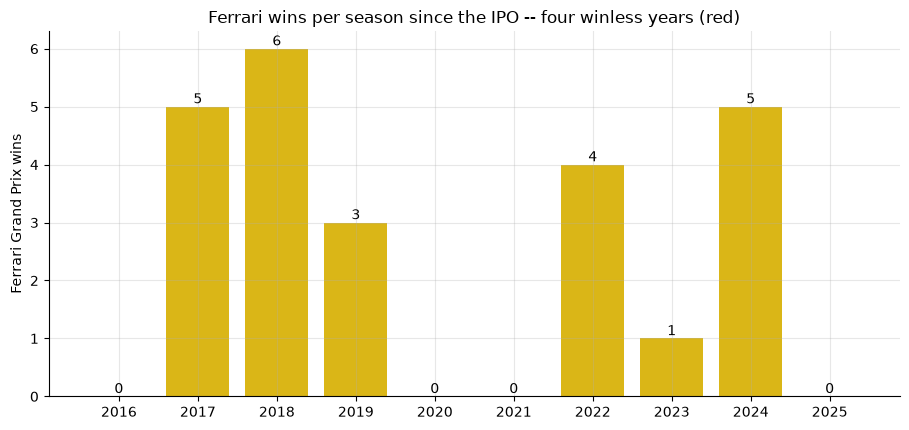

total wins: 24


In [2]:
wbs = (dict(sorted(({s: int((INC['season']==s).sum()) for s in range(2016,2026)}).items()))
       if HAVE_REAL else R['wins_by_season'])
seasons = list(wbs); wins = [wbs[s] for s in seasons]
cols = [RED if w == 0 else AMBER for w in wins]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar([str(s) for s in seasons], wins, color=cols)
ax.set_ylabel('Ferrari Grand Prix wins')
ax.set_title('Ferrari wins per season since the IPO -- four winless years (red)')
for i, w in enumerate(wins): ax.annotate(str(w), (i, w), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print('total wins:', sum(wins))

24 wins over a decade, lumpy: a strong 2017-18 (Vettel fighting for the title), a thin middle, a 2022-24 revival, and four completely winless seasons. Hold that lumpiness in mind — it turns out to matter.

**Now the headline: does RACE actually pop on win-Mondays?**

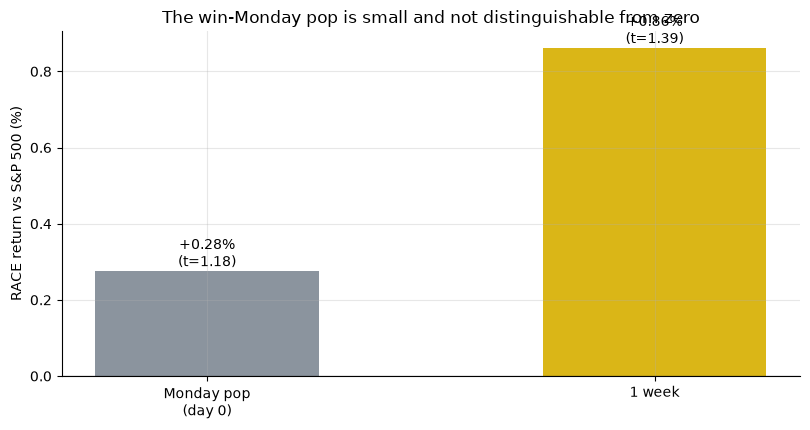

day0 +0.276% (t=1.18) | week +0.862% (t=1.39)


In [3]:
if HAVE_REAL:
    d = st.one_sample_t(INC['ar_day'].values)
    w = st.one_sample_t(INC['ar_week'].values)
    dm, dt_, wm, wt = d['mean']*100, d['t'], w['mean']*100, w['t']
else:
    dm, dt_, wm, wt = R['d_mean'], R['d_t'], R['wk_mean'], R['wk_t']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
bars = ax.bar(['Monday pop\n(day 0)', '1 week'], [dm, wm],
              color=[GREY, AMBER], width=.5)
for b, v, t in zip(bars, [dm, wm], [dt_, wt]):
    ax.annotate(f'{v:+.2f}%\n(t={t:.2f})', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('RACE return vs S&P 500 (%)')
ax.set_title('The win-Monday pop is small and not distinguishable from zero')
plt.tight_layout(); plt.show()
print(f'day0 {dm:+.3f}% (t={dt_:.2f}) | week {wm:+.3f}% (t={wt:.2f})')

RACE is up **+0.28%** vs the market on the Monday after a win — but *t* = **1.18**, nowhere near the desk's bar of 2, and the win-Mondays are green only **13 times out of 24** (54%). That's a coin flip. **Is a win-Monday even different from a random Monday?**

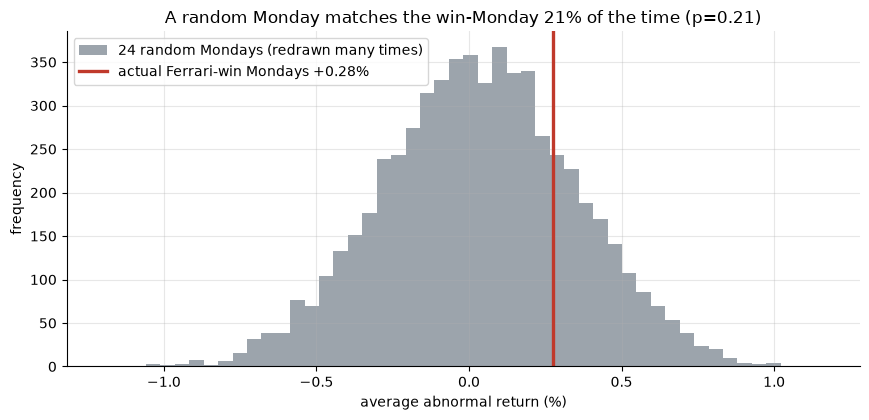

In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(EV, PRICES, 'ar_day', k=1, entry_offset=0,
                           n_seeds=6, n_draws_per_seed=500, tail='right')
    obs = pl['obs']*100
    rng = np.random.default_rng(730)
    draws = rng.normal(pl['placebo_mean'], pl['placebo_sd'], 6000)*100
else:
    obs = R['d_mean']
    rng = np.random.default_rng(730)
    draws = rng.normal(R['pl_d_mean'], R['pl_d_sd'], 6000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='24 random Mondays (redrawn many times)')
ax.axvline(obs, c=RED, lw=2.4, label=f'actual Ferrari-win Mondays {obs:+.2f}%')
ax.set_xlabel('average abnormal return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'A random Monday matches the win-Monday {int(R["pl_d_p"]*100)}% of the time (p={R["pl_d_p"]:.2f})')
ax.legend(); plt.tight_layout(); plt.show()

The red line — the real Ferrari-win average — sits comfortably inside the grey cloud of random Mondays (**p = 0.21**). Statistically, a Ferrari win tells you nothing about Monday that a coin wouldn't.

**And the shape is wrong too.** A fan reaction to a Sunday win should be a *Monday jump* that holds:

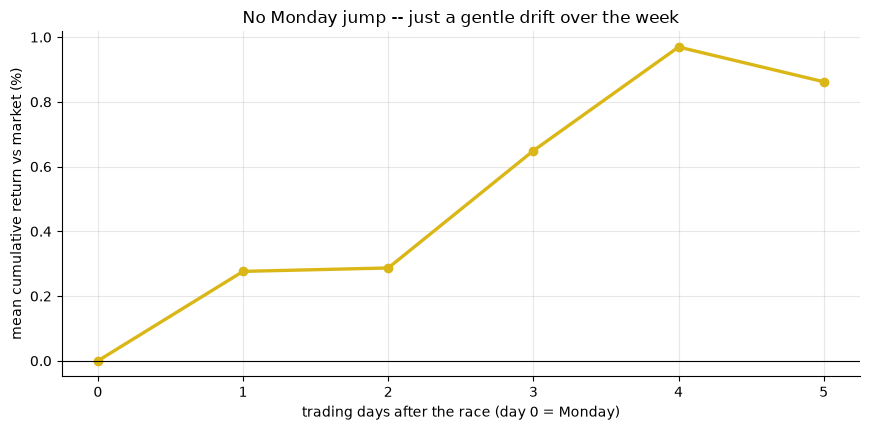

In [5]:
if HAVE_REAL:
    cp = st.car_path(EV, PRICES, max_k=5)
    days = list(cp.index); ys = list(cp.values*100)
else:
    days = sorted(R['car']); ys = [R['car'][k] for k in days]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.plot(days, ys, color=AMBER, lw=2.4, marker='o')
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('trading days after the race (day 0 = Monday)')
ax.set_ylabel('mean cumulative return vs market (%)')
ax.set_title('No Monday jump -- just a gentle drift over the week')
plt.tight_layout(); plt.show()

There's no broadcast-night pop. The Monday move is tiny; the line just drifts up slowly over the following days — the signature of ordinary single-stock noise, not an event reaction.

**Here's the twist, and it's the whole study.** Split the 24 wins into two kinds: the **2017-18** wins, when Ferrari were genuinely fighting for the championship (a win *meant something* for the title), versus the **one-off** wins in years they finished nowhere (pure 'we won a race' celebration):

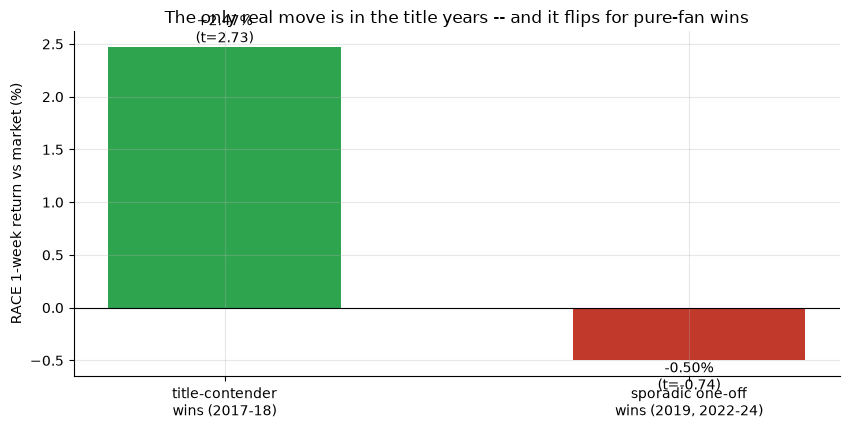

contender +2.47% (t=2.73) | sporadic -0.50% (t=-0.74)


In [6]:
if HAVE_REAL:
    cwm = st.one_sample_t(CONT['ar_week'].values); swm = st.one_sample_t(SPOR['ar_week'].values)
    cw, cwt, sw, swt = cwm['mean']*100, cwm['t'], swm['mean']*100, swm['t']
else:
    cw, cwt, sw, swt = R['cont_wk_mean'], R['cont_wk_t'], R['spor_wk_mean'], R['spor_wk_t']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
bars = ax.bar(['title-contender\nwins (2017-18)', 'sporadic one-off\nwins (2019, 2022-24)'],
              [cw, sw], color=[GREEN, RED], width=.5)
for b, v, t in zip(bars, [cw, sw], [cwt, swt]):
    ax.annotate(f'{v:+.2f}%\n(t={t:.2f})', (b.get_x()+b.get_width()/2, v),
                ha='center', va=('bottom' if v>=0 else 'top'))
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('RACE 1-week return vs market (%)')
ax.set_title('The only real move is in the title years -- and it flips for pure-fan wins')
plt.tight_layout(); plt.show()
print(f'contender {cw:+.2f}% (t={cwt:.2f}) | sporadic {sw:+.2f}% (t={swt:.2f})')

There it is. The **title-contender** wins move RACE **+2.47%** over the week (*t* = 2.73 — the one number in the whole study that clears the bar). The **sporadic** wins — the ones that are *only* about fan joy — go **-0.50%**, slightly *negative*. If this were a tifosi brand-halo, the sporadic wins should show it just as much. They show the opposite. Whatever moved RACE in 2017-18 was the market repricing a live championship — money, momentum, a real title shot — not the crowd's mood.

## 5 · The verdict

- **Signal — None.** The fan-halo win pop the folklore predicts just isn't there: RACE is up a statistically-invisible **+0.28%** on win-Mondays (*t* = 1.18), green barely more than half the time, and no different from a random Monday.
- **Tradability — Mirage.** The best honest, after-the-news trade nets **+0.48%** over a week — a random-window draw. Nothing to size.
- **Fan-halo, or fundamentals? — Misattributed.** The one signal that survives lives entirely in the title-contender years and *reverses* for the pure-celebration wins. The little that's real is the scoreboard repricing a championship, not the tifosi lifting the brand.

## 6 · Going further 🚪

- **This is a clean example of a *mislabeled* effect.** There's a real wisp in the data — but it's the wrong story. The desk's job isn't just 'real / not real', it's *'real because of what you think?'* Here the honest answer is no.
- **A sharper test** would net out luxury-sector beta (RACE vs an LVMH / Hermès basket, not just SPY), so a 'Ferrari-specific' pop couldn't hide inside a good week for luxury; and it would add *podiums* and *losses* (does a shock DNF hurt more than a win helps, the Edmans asymmetry?).
- **Sibling studies:** the [Eurovision effect](../../708-eurovision-effect/) (national-pride bump from a cultural contest), the [World Cup effect](../../235-world-cup-effect/) (the real Edmans mechanism on the S&P 500), and the [plane-crash effect](../../707-plane-crash-effect/) (a dread-sentiment shock) — each a mood-moves-markets claim, tested the same honest way.

*Think the tifosi really move RACE? Net out luxury beta, add losses and podiums, and show a positive, replicated, placebo-surviving pop that *doesn't* vanish once you control for the championship. We'll publish the teardown.*